# Robustness Analysis for Research Questions

*Author: Martine Klep*  
*Date: 03-05-2026*

This script performs the robustness analysis for the selected acoustic features. The analysis evaluates how much each feature changes after applying different perturbations to the audio data.
For the three research questions

- RQ1: “Which vocal features are most affected by different types and levels of perturbations?”
  -  Feature sensitivity was evaluated by comparing each perturbed dataset with its corresponding original dataset, using standardisation based on the original reference data within each perturbation analysis.

- RQ2: “Do the effects of intensity, low-pass, pink noise, and Gaussian perturbations differ between the original dataset and the dataset processed with Wiener filtering?” 
  - Feature sensitivity was compared between the original and Wiener-preprocessed datasets using one shared scaler fitted on the clean original dataset, allowing direct comparison between both preprocessing conditions.

- RQ3: “How does the impact of perturbations vary across pain groups?” 
  - Feature sensitivity was evaluated separately for the mild, moderate, and severe pain groups, using standardisation based on the original reference data within each pain-group analysis.

# Research question 1: “Which vocal features are most affected by different types and levels of perturbations?”


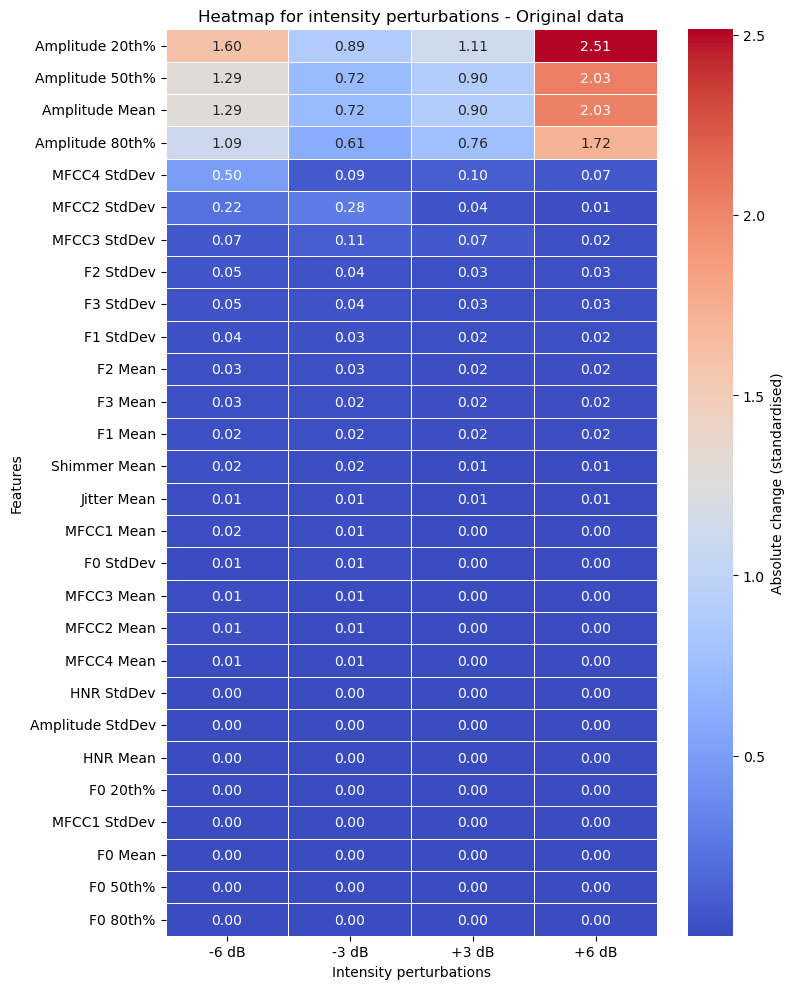

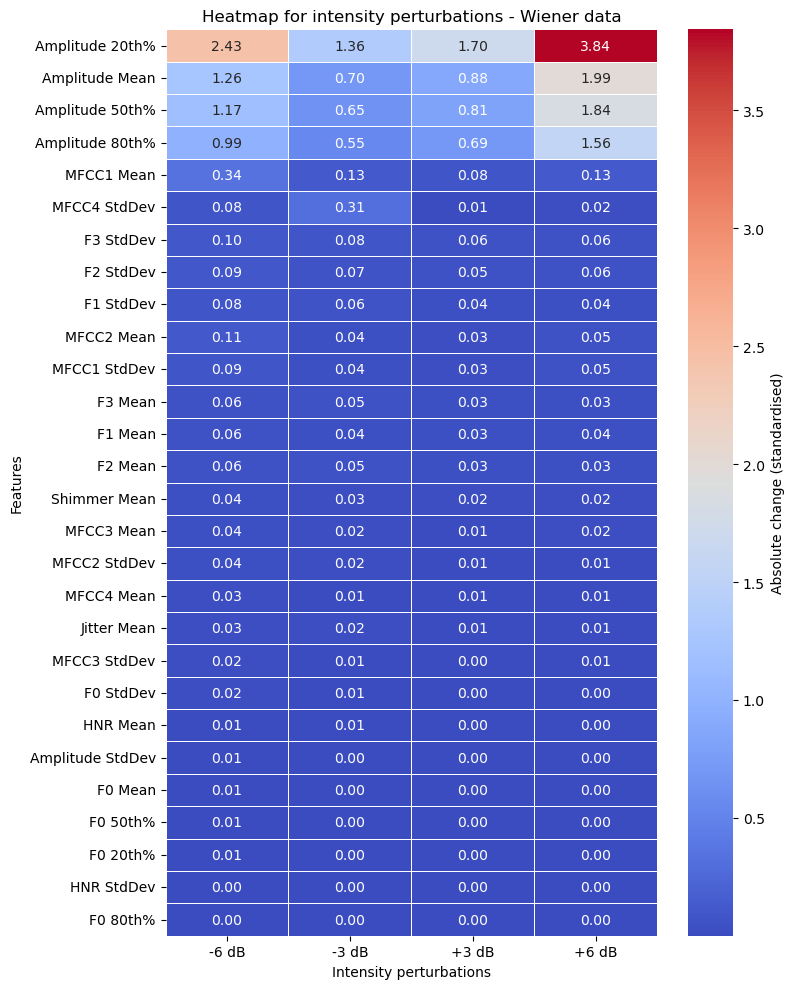

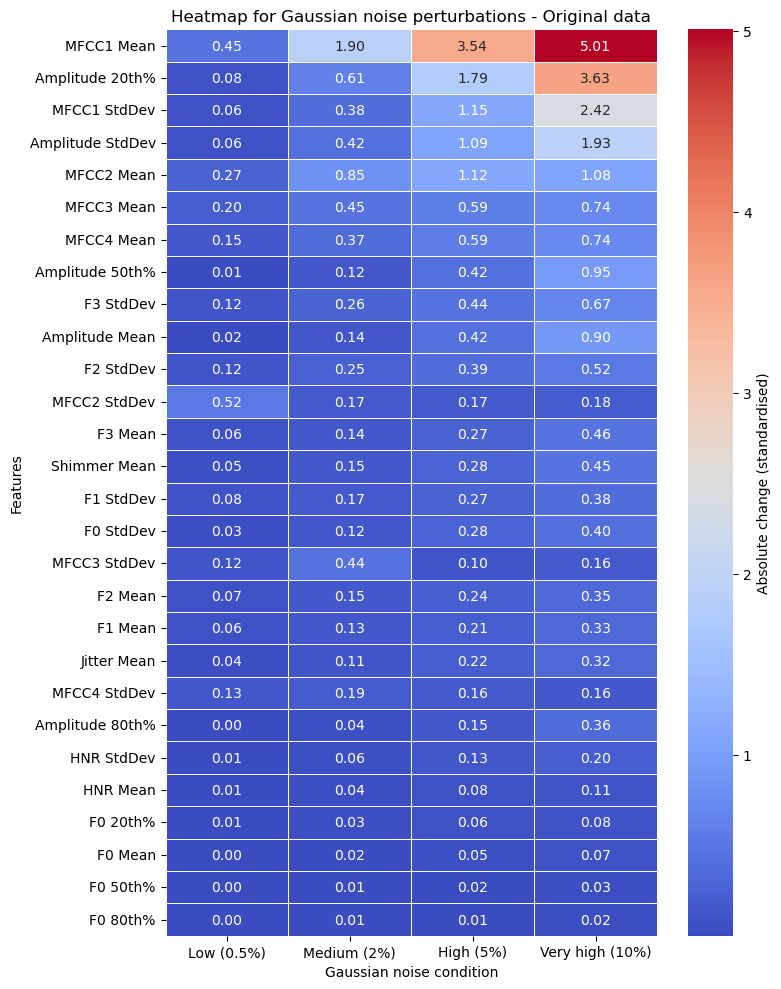

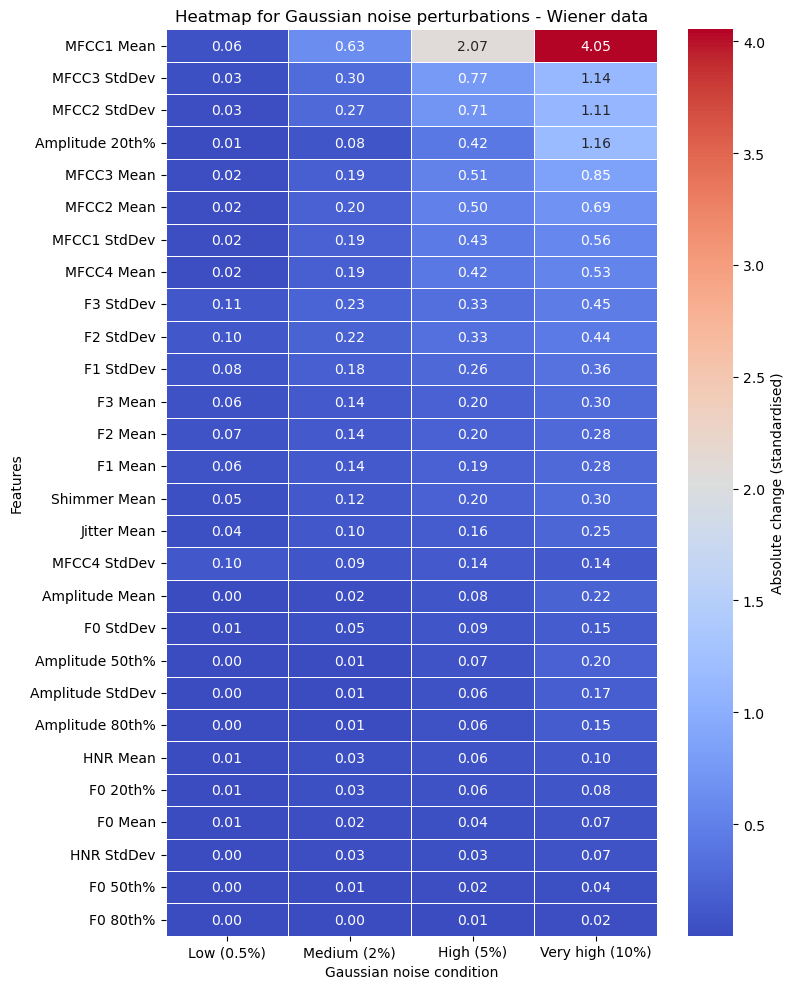

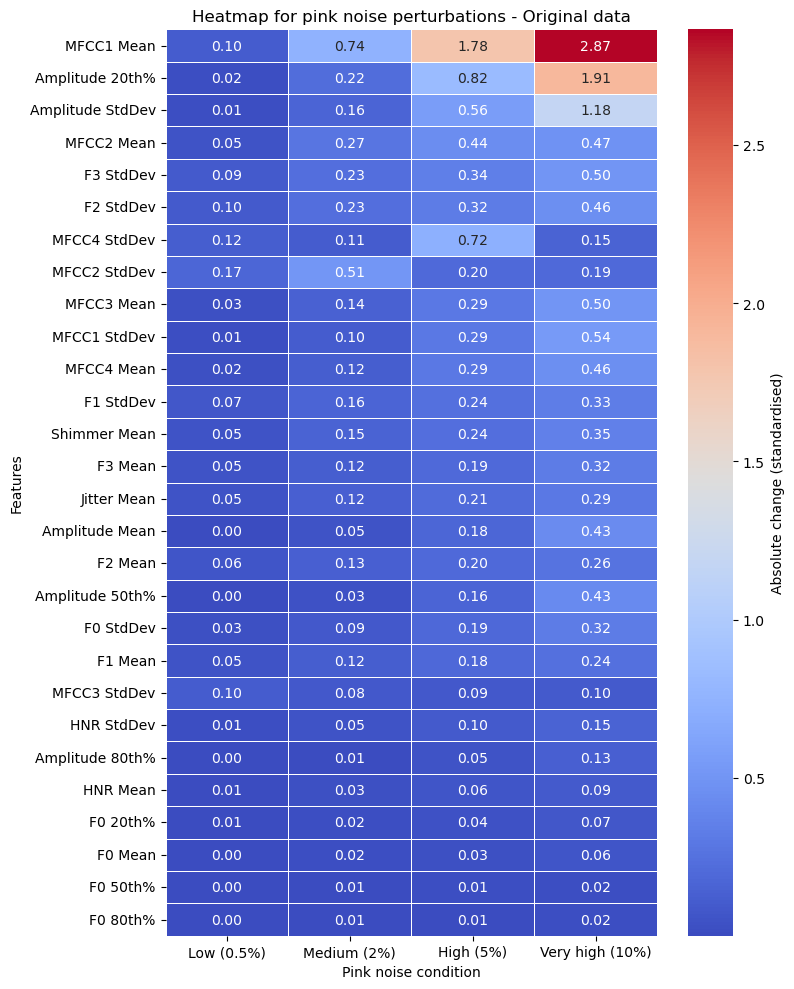

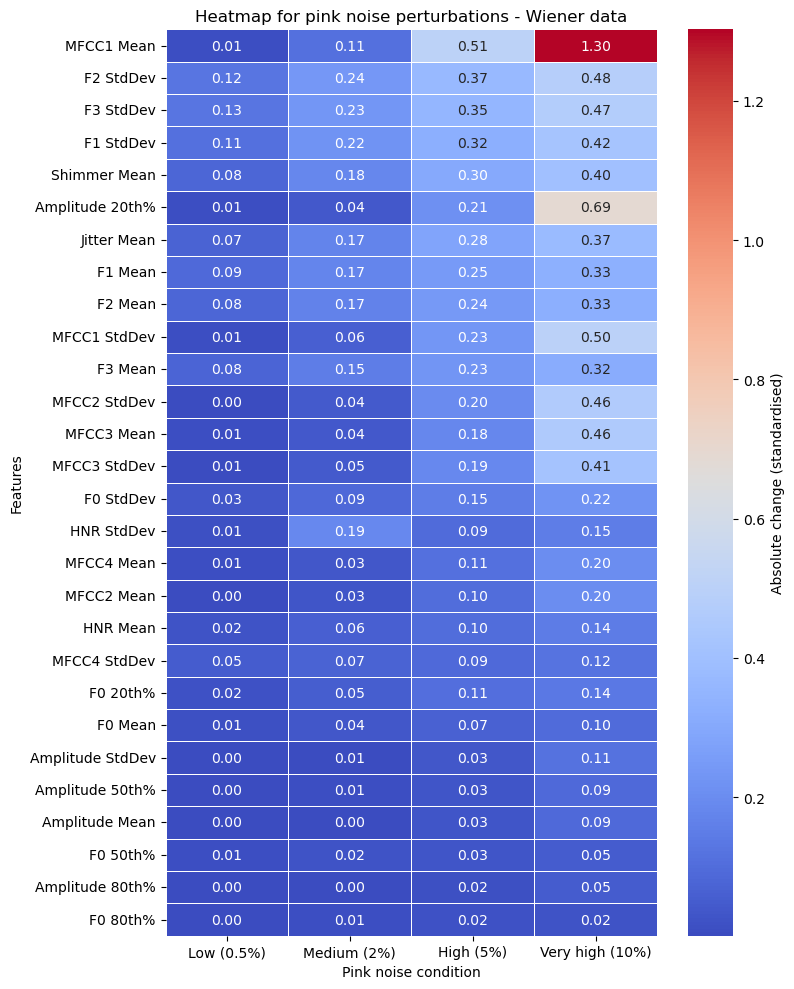

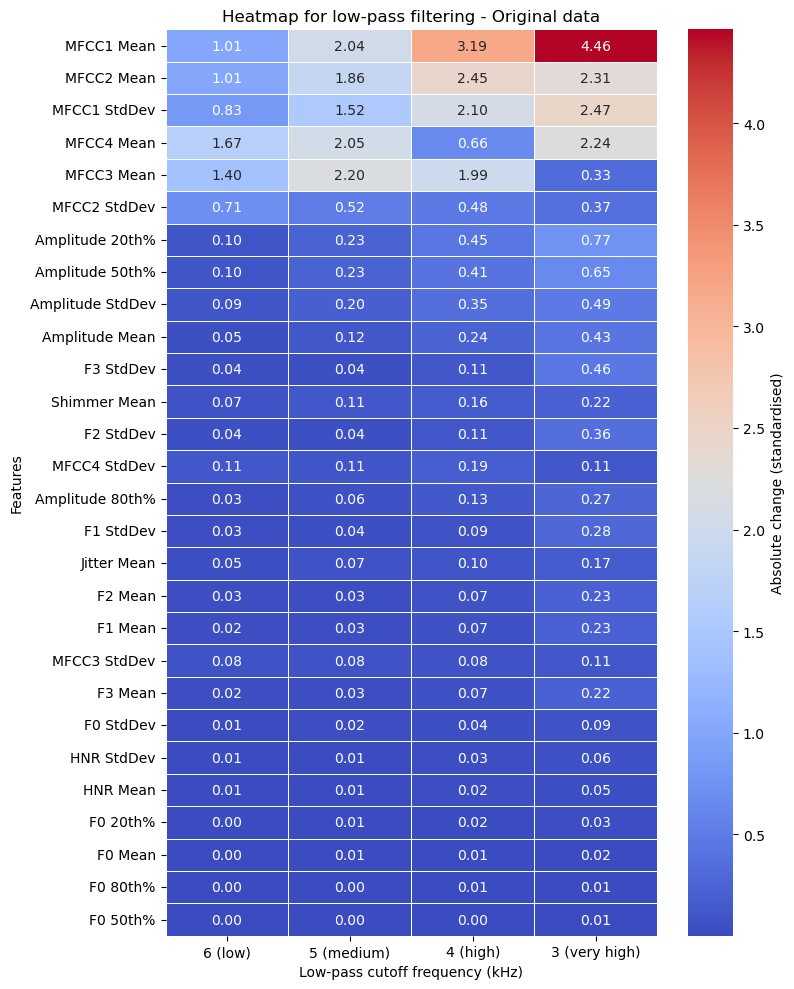

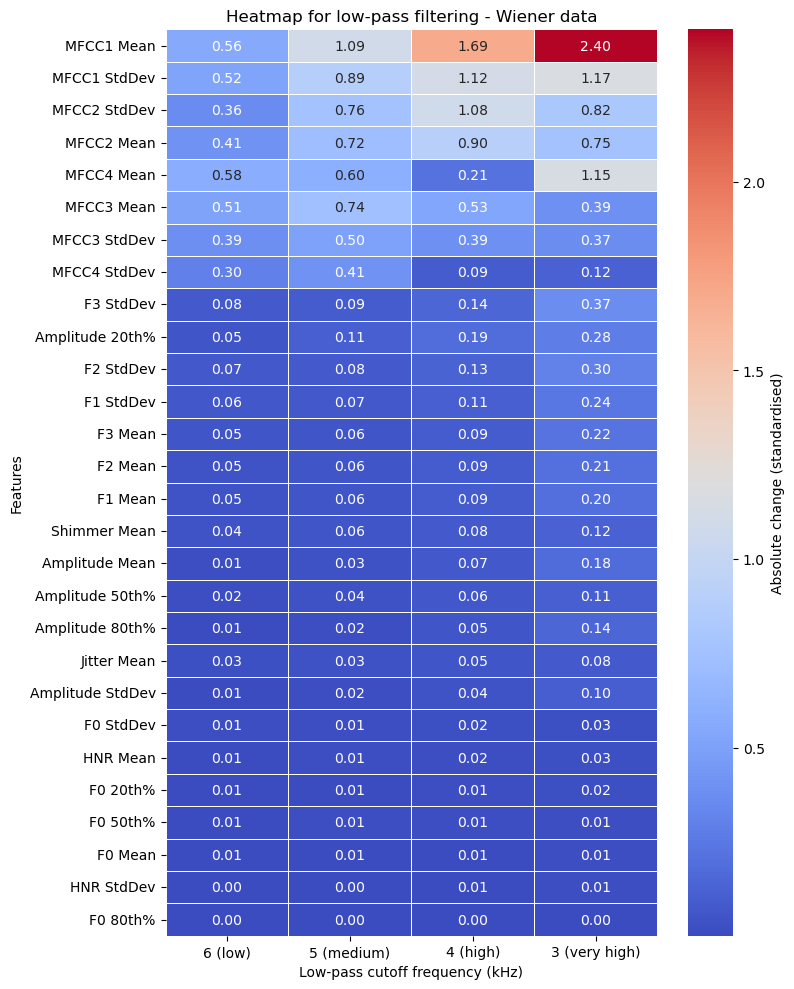

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


# Paths
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

# Selected features
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# Robustness evaluation configuration
ROBUSTNESS_CONFIG = {
    "intensity": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "-6 dB": {
                "original": "opensmile_original_intensity_-6dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_-6dB_pain.csv",
            },
            "-3 dB": {
                "original": "opensmile_original_intensity_-3dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_-3dB_pain.csv",
            },
            "+3 dB": {
                "original": "opensmile_original_intensity_3dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_3dB_pain.csv",
            },
            "+6 dB": {
                "original": "opensmile_original_intensity_6dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_6dB_pain.csv",
            },
        },
        "xlabel": "Intensity perturbations",
        "title": "Heatmap for intensity perturbations",
    },
    "gaussian_noise": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_original_gaussian_low_pain.csv",
                "wiener": "opensmile_wiener_gaussian_low_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_original_gaussian_medium_pain.csv",
                "wiener": "opensmile_wiener_gaussian_medium_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_original_gaussian_high_pain.csv",
                "wiener": "opensmile_wiener_gaussian_high_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_original_gaussian_very_high_pain.csv",
                "wiener": "opensmile_wiener_gaussian_very_high_pain.csv",
            },
        },
        "xlabel": "Gaussian noise condition",
        "title": "Heatmap for Gaussian noise perturbations",
    },
    "pink_noise": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_original_pink_low_pain.csv",
                "wiener": "opensmile_wiener_pink_low_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_original_pink_medium_pain.csv",
                "wiener": "opensmile_wiener_pink_medium_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_original_pink_high_pain.csv",
                "wiener": "opensmile_wiener_pink_high_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_original_pink_very_high_pain.csv",
                "wiener": "opensmile_wiener_pink_very_high_pain.csv",
            },
        },
        "xlabel": "Pink noise condition",
        "title": "Heatmap for pink noise perturbations",
    },
    "lowpass": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "6 (low)": {
                "original": "opensmile_original_lowpass_low_pain.csv",
                "wiener": "opensmile_wiener_lowpass_low_pain.csv",
            },
            "5 (medium)": {
                "original": "opensmile_original_lowpass_medium_pain.csv",
                "wiener": "opensmile_wiener_lowpass_medium_pain.csv",
            },
            "4 (high)": {
                "original": "opensmile_original_lowpass_high_pain.csv",
                "wiener": "opensmile_wiener_lowpass_high_pain.csv",
            },
            "3 (very high)": {
                "original": "opensmile_original_lowpass_very_high_pain.csv",
                "wiener": "opensmile_wiener_lowpass_very_high_pain.csv",
            },
        },
        "xlabel": "Low-pass cutoff frequency (kHz)",
        "title": "Heatmap for low-pass filtering",
    },
}

EXCLUDE_COLS = ["participant_id", "filename", "file_path", "name"]

# Functions
def load_and_sort_csv(file_path):
    """
    Load a CSV file and sort it by participant_id and filename to ensure consistent ordering across datasets.
    """
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def validate_matching_ids(reference_df, comparison_dfs):
    """
    Validate that the participant_id and filename columns match across all datasets, ensuring that rows correspond to the same recordings.
    """
    reference_ids = reference_df[["participant_id", "filename"]]

    for name, df in comparison_dfs.items():
        current_ids = df[["participant_id", "filename"]]
        if not reference_ids.equals(current_ids):
            raise ValueError(f"Mismatch in {name}")


def get_selected_feature_cols(df, selected_features_dict):
    """
    Get the actual column names for the selected features based on the provided mapping, and validate that they exist in the dataframe.
    """
    missing_features = [col for col in selected_features_dict.values() if col not in df.columns]
    if missing_features:
        raise ValueError(f"Deze selected features ontbreken in de data:\n{missing_features}")
    return list(selected_features_dict.values())


def standardize_against_reference(dfs, feature_cols, reference_key="original"):
    """
    Standardize the feature columns in all datasets using the mean and std from the reference dataset (original).
    This ensures that the absolute differences are on the same scale across all conditions.
    """
    scaler = StandardScaler()
    scaler.fit(dfs[reference_key][feature_cols])

    dfs_std = {}
    for key, df in dfs.items():
        df_std = df.copy()
        df_std[feature_cols] = scaler.transform(df[feature_cols])
        dfs_std[key] = df_std

    return dfs_std


def compute_abs_diff_heatmap_df(dfs_std, feature_cols, condition_order, reference_key="original"):
    """
    Compute a dataframe for the heatmap that contains the mean absolute difference of each feature compared to the reference dataset, for each condition.
    """

    original_features = dfs_std[reference_key][feature_cols]
    abs_diff_means = {}

    for condition in condition_order:
        perturbed_features = dfs_std[condition][feature_cols]
        abs_diff = np.abs(perturbed_features - original_features)
        abs_diff_means[condition] = abs_diff.mean(axis=0)

    heatmap_df = pd.DataFrame(abs_diff_means, index=feature_cols)
    heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
    heatmap_df = heatmap_df.drop(columns=["mean_change"])

    return heatmap_df


def rename_heatmap_index(heatmap_df, selected_features_dict):
    """
    Rename the index of the heatmap dataframe from the actual column names back to the more readable feature names using the provided mapping.
    """
    reverse_mapping = {v: k for k, v in selected_features_dict.items()}
    heatmap_df = heatmap_df.copy()
    heatmap_df.index = [reverse_mapping.get(idx, idx) for idx in heatmap_df.index]
    return heatmap_df


def plot_heatmap(
    heatmap_df,
    title,
    xlabel,
    ylabel="Features",
    figsize=(8, 10)
):
    """
    Plot a heatmap of the mean absolute differences for the features across conditions.
    """
    plt.figure(figsize=figsize)
    sns.heatmap(
        heatmap_df,
        cmap="coolwarm",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Absolute change (standardised)"},
        annot=True,
        fmt=".2f"
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def run_robustness_evaluation_selected_features(
    base_path,
    config,
    data_type,
    selected_features_dict,
    save_csv=False
):
    """
    data_type = 'original' of 'wiener'
    config = one of de configuraties in ROBUSTNESS_CONFIG
    selected_features_dict = mapping of display names to actual column names for the selected features
    """
    files = {
        "original": base_path / config[data_type]
    }

    for condition_name, paths in config["conditions"].items():
        files[condition_name] = base_path / paths[data_type]

    dfs = {name: load_and_sort_csv(path) for name, path in files.items()}

    validate_matching_ids(
        reference_df=dfs["original"],
        comparison_dfs={k: v for k, v in dfs.items() if k != "original"}
    )

    feature_cols = get_selected_feature_cols(dfs["original"], selected_features_dict)
    dfs_std = standardize_against_reference(dfs, feature_cols, reference_key="original")

    condition_order = list(config["conditions"].keys())
    heatmap_df = compute_abs_diff_heatmap_df(
        dfs_std=dfs_std,
        feature_cols=feature_cols,
        condition_order=condition_order,
        reference_key="original"
    )

    heatmap_df = rename_heatmap_index(heatmap_df, selected_features_dict)

    if save_csv:
        output_name = f"robustness_selected_features_{data_type}_{config['title'].lower().replace(' ', '_')}.csv"
        heatmap_df.to_csv(base_path / output_name)

    plot_heatmap(
        heatmap_df=heatmap_df,
        title=f"{config['title']} - {data_type.capitalize()} data",
        xlabel=config["xlabel"]
    )

    return heatmap_df


# Run robustness evaluation for all perturbations and both original and wiener data with selected features
results_selected = {}

for perturbation_name, config in ROBUSTNESS_CONFIG.items():
    results_selected[(perturbation_name, "original")] = run_robustness_evaluation_selected_features(
        base_path=BASE_PATH,
        config=config,
        data_type="original",
        selected_features_dict=selected_features,
        save_csv=False
    )

    results_selected[(perturbation_name, "wiener")] = run_robustness_evaluation_selected_features(
        base_path=BASE_PATH,
        config=config,
        data_type="wiener",
        selected_features_dict=selected_features,
        save_csv=False
    )

# Question 2: “Do the effects of intensity, low-pass, pink noise, and Gaussian perturbations differ between the original dataset and the dataset processed with Wiener filtering?” 

RUN_ORIGINAL = True
RUN_WIENER = True

===== Running wiener =====
Feature sensitivity table saved to:
C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_original_based_scaling_wiener.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.003491        0.031695    0.050646         0.008613
F0 20th%           0.003889        0.055811    0.093193         0.015563
F0 50th%           0.003642        0.020201    0.027917         0.012668
F0 80th%           0.001011        0.009919    0.014202         0.002692
F0 StdDev          0.016553        0.145646    0.238537         0.035281
F1 Mean            0.041909        0.160459    0.202259         0.093105
F1 StdDev          0.046679        0.184091    0.223199         0.099867
F2 Mean            0.038842        0.155577    0.184460         0.089319
F2 StdDev          0.061058        0.245382    0.271766         0.132314
F3 Mean            

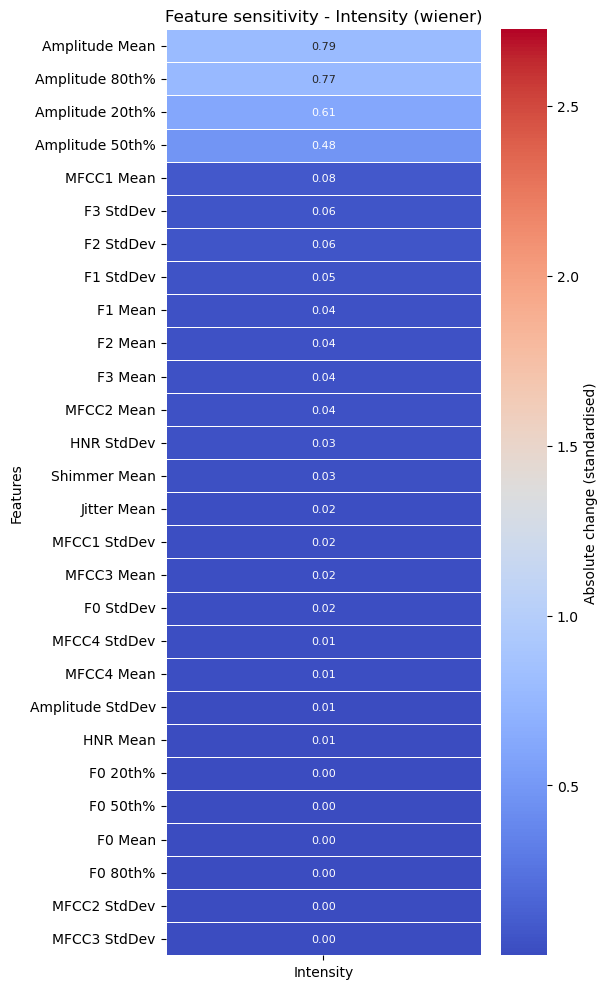

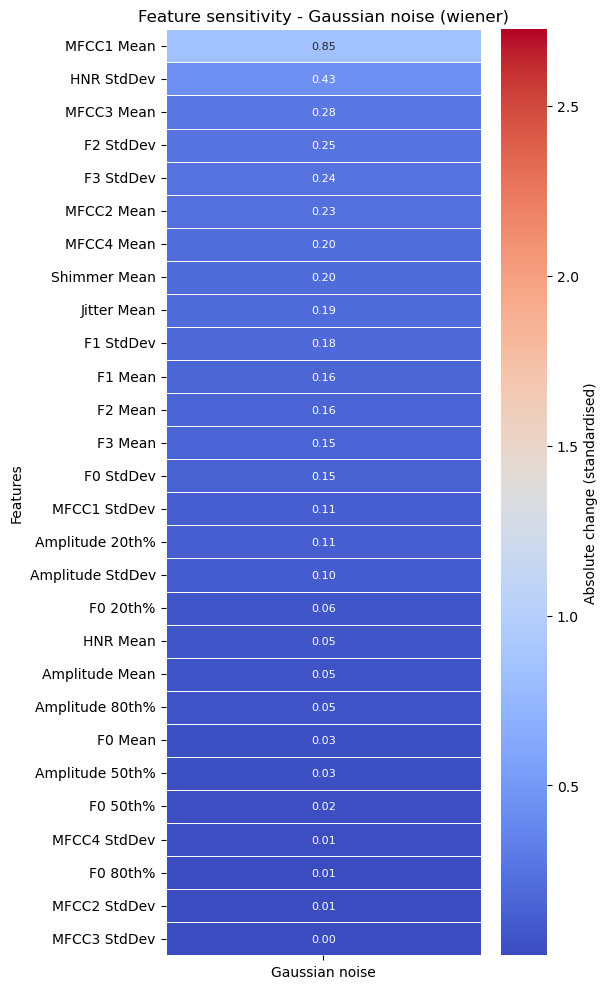

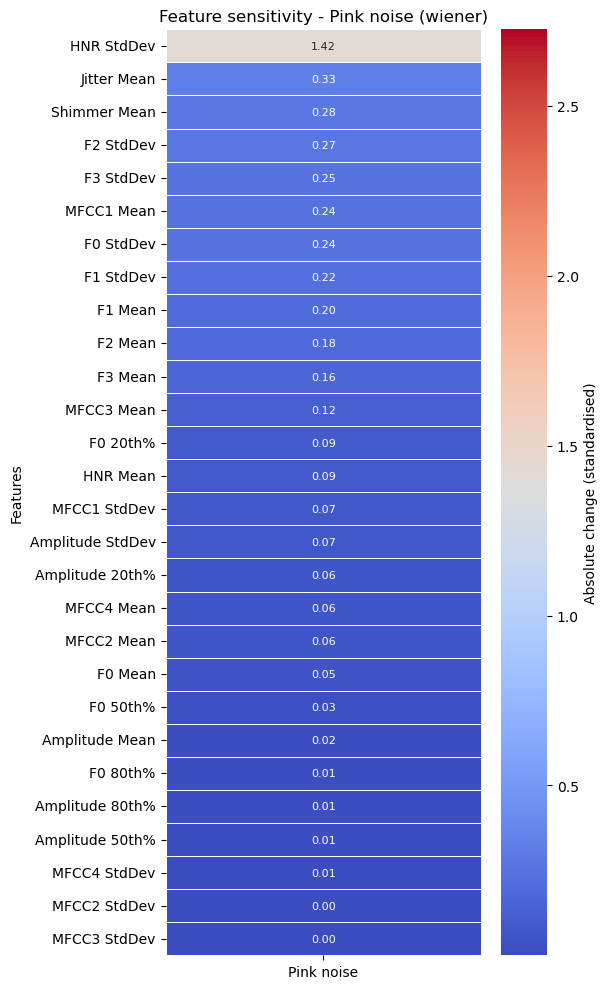

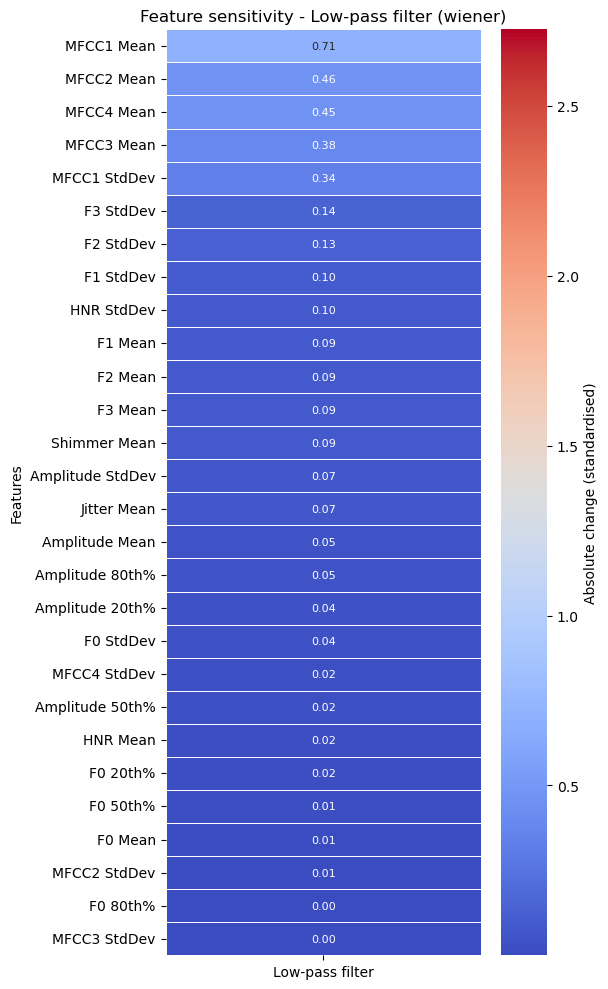

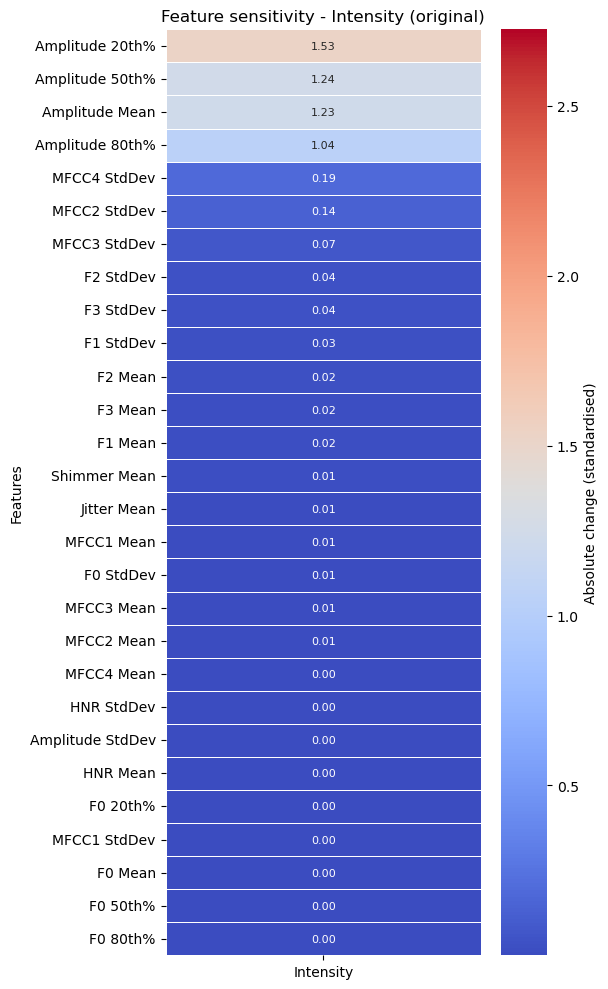

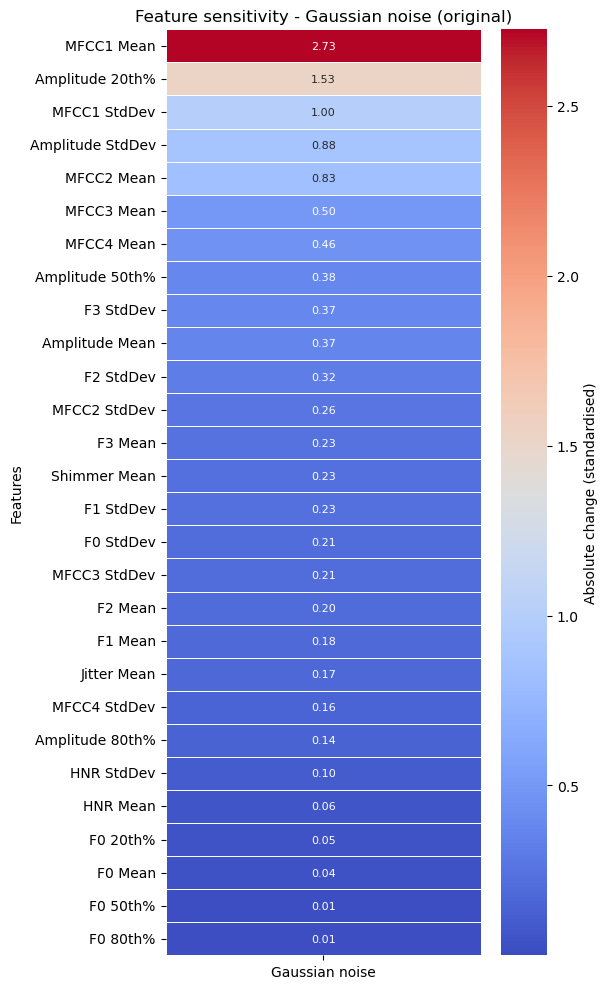

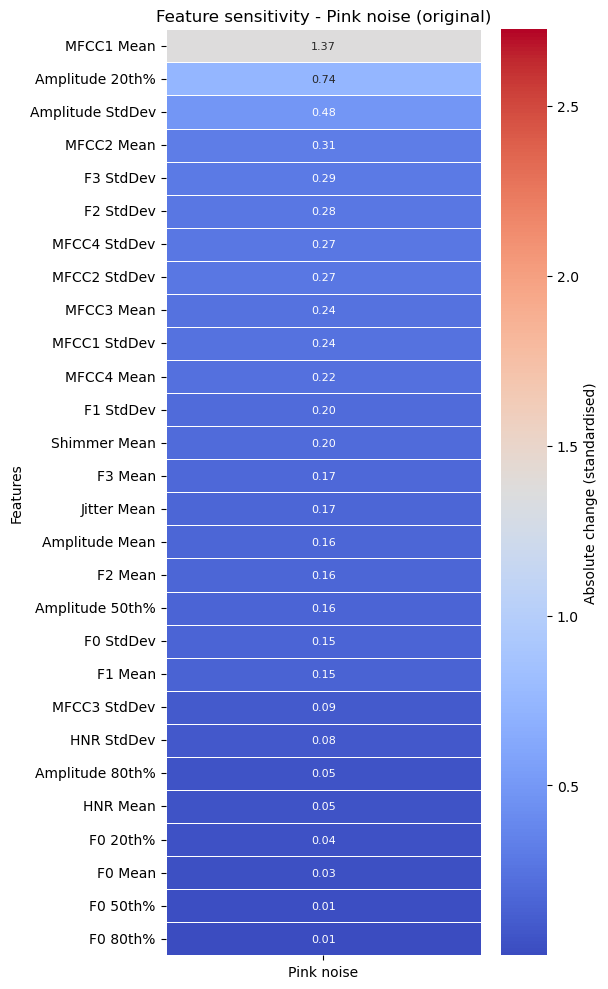

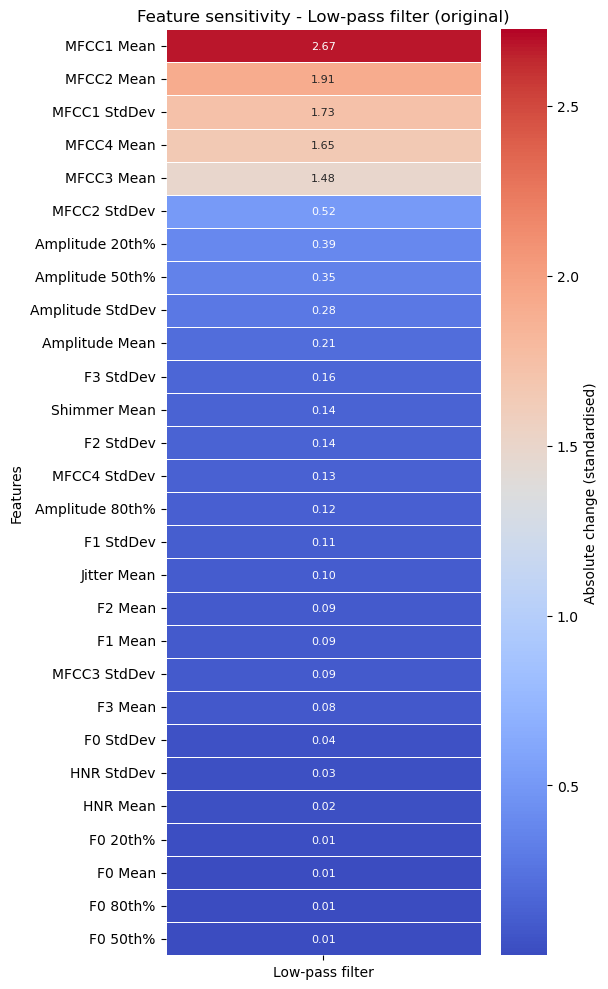

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# =========================
# Paths + settings
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

RUN_ORIGINAL = True
RUN_WIENER = True

OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_original_based_scaling_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_original_based_scaling_wiener.csv",
}

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation_original_based_scaling"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

# Features selection
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# Perturbation groups and their corresponding files
PERTURBATION_GROUPS = {}

if RUN_WIENER:
    PERTURBATION_GROUPS["wiener"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "-6": BASE_PATH / "opensmile_wiener_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_wiener_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_wiener_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_wiener_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "6000": BASE_PATH / "opensmile_wiener_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_wiener_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_wiener_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_wiener_lowpass_very_high_pain.csv",
        },
    }

if RUN_ORIGINAL:
    PERTURBATION_GROUPS["original"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "-6": BASE_PATH / "opensmile_original_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_original_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_original_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_original_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "6000": BASE_PATH / "opensmile_original_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_original_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_original_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_original_lowpass_very_high_pain.csv",
        },
    }

if not PERTURBATION_GROUPS:
    raise ValueError("Set RUN_ORIGINAL and/or RUN_WIENER to True.")

# Functions
def load_and_sort_csv(file_path):
    """
    Load a CSV file and sort it by participant_id and filename to ensure consistent ordering across datasets.
    """
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def check_alignment(reference_df, comparison_df, label):
    """
    Check that the participant_id and filename columns match between the reference and comparison dataframes.
    This ensures that we are comparing the same recordings across datasets.
    """
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


def fit_shared_scaler_on_original_clean(base_path, feature_cols):
    """
    Fit a StandardScaler on the original clean data, using only the selected features. This scaler will be used to standardize all datasets to ensure that the absolute differences are on the same scale.
    """
    original_clean_path = base_path / "opensmile_original_pain.csv"
    original_clean_df = load_and_sort_csv(original_clean_path)

    missing_features = [
        feature_col for feature_col in feature_cols
        if feature_col not in original_clean_df.columns
    ]
    if missing_features:
        raise ValueError(
            f"These features are missing from the original clean CSV: {missing_features}"
        )

    scaler = StandardScaler()
    scaler.fit(original_clean_df[feature_cols])
    return scaler


def run_sensitivity_analysis(perturbation_groups, output_file, shared_scaler):
    """
    Calculate feature sensitivity per perturbation group.

    Standardization is performed using ONE shared scaler fitted on
    original clean data. That scaler is applied to:
    - original clean
    - original perturbations
    - wiener clean
    - wiener perturbations
    """
    all_data = {}

    for group_name, files in perturbation_groups.items():
        all_data[group_name] = {}
        for level_label, file_path in files.items():
            all_data[group_name][level_label] = load_and_sort_csv(file_path)

    for group_name, dfs in all_data.items():
        original_df = dfs["original"]
        for level_label, df in dfs.items():
            if level_label == "original":
                continue
            check_alignment(original_df, df, f"{group_name} - {level_label}")

    reference_original = all_data["Intensity"]["original"]
    feature_cols = list(selected_features.values())

    missing_features = [
        feature_col
        for feature_col in feature_cols
        if feature_col not in reference_original.columns
    ]
    if missing_features:
        raise ValueError(f"These features are missing from the CSV files: {missing_features}")

    results = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    for group_name, dfs in all_data.items():
        original_std = shared_scaler.transform(dfs["original"][feature_cols])

        for i, feature_name in enumerate(selected_features.keys()):
            level_scores = []

            for level_label, df in dfs.items():
                if level_label == "original":
                    continue

                perturbed_std = shared_scaler.transform(df[feature_cols])

                abs_diff = np.abs(original_std[:, i] - perturbed_std[:, i])
                level_scores.append(abs_diff.mean())

            results.loc[feature_name, group_name] = np.mean(level_scores)

    results.to_csv(output_file)

    print("Feature sensitivity table saved to:")
    print(output_file)
    print()
    print(results)

    return results


def save_heatmaps(results_df, dataset_name, heatmap_dir, vmin=None, vmax=None):
    """
    Save heatmaps for each perturbation group with a shared color scale.
    """

    dataset_heatmap_dir = heatmap_dir / dataset_name
    dataset_heatmap_dir.mkdir(parents=True, exist_ok=True)

    for group_name in results_df.columns:
        heatmap_data = results_df[[group_name]].copy()
        heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

        plt.figure(figsize=(6, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax,
            cbar_kws={"label": "Absolute change (standardised)"},
            linewidths=0.5,
            cbar=True,
            annot_kws={"size": 8}
        )

        plt.title(f"Feature sensitivity - {group_name} ({dataset_name})")
        plt.xlabel("")
        plt.ylabel("Features")
        plt.tight_layout()

        plt.savefig(
            dataset_heatmap_dir / f"heatmap_{group_name.replace(' ', '_')}_{dataset_name}.png",
            dpi=300
        )
        plt.show()
        plt.close()


# Run the analysis and save results
all_results = {}

print("RUN_ORIGINAL =", RUN_ORIGINAL)
print("RUN_WIENER =", RUN_WIENER)
print()

feature_cols = list(selected_features.values())
shared_scaler = fit_shared_scaler_on_original_clean(BASE_PATH, feature_cols)

for dataset_name, perturbation_groups in PERTURBATION_GROUPS.items():
    print(f"===== Running {dataset_name} =====")

    results = run_sensitivity_analysis(
        perturbation_groups=perturbation_groups,
        output_file=OUTPUT_FILES[dataset_name],
        shared_scaler=shared_scaler
    )

    all_results[dataset_name] = results
    print()

# Compute global vmin and vmax across all heatmaps to ensure consistent color scaling
all_values = []
for dataset_name, results in all_results.items():
    all_values.append(results.values.flatten())

all_values = np.concatenate(all_values)
global_vmin = np.nanmin(all_values)
global_vmax = np.nanmax(all_values)

print("Global heatmap color scale:")
print("vmin =", global_vmin)
print("vmax =", global_vmax)
print()

# Save heatmaps 
for dataset_name, results in all_results.items():
    save_heatmaps(
        results_df=results,
        dataset_name=dataset_name,
        heatmap_dir=HEATMAP_DIR,
        vmin=global_vmin,
        vmax=global_vmax
    )

# Question 3: “How does the impact of perturbations vary across pain groups?” 

===== Running wiener_pain_group_1_to_4 =====
Feature sensitivity table saved to:
C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_original_based_scaling_wiener_pain_group_1_to_4.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.004423        0.030713    0.055222         0.007627
F0 20th%           0.001634        0.029361    0.053111         0.003798
F0 50th%           0.001374        0.008079    0.016465         0.005626
F0 80th%           0.001204        0.008545    0.018041         0.003809
F0 StdDev          0.009574        0.071212    0.137169         0.016008
F1 Mean            0.040176        0.162561    0.203991         0.094223
F1 StdDev          0.052745        0.198886    0.242909         0.108540
F2 Mean            0.040062        0.164952    0.195898         0.095182
F2 StdDev          0.063006        0.255754    0.292098         0.148308
F3 Mean            0.0

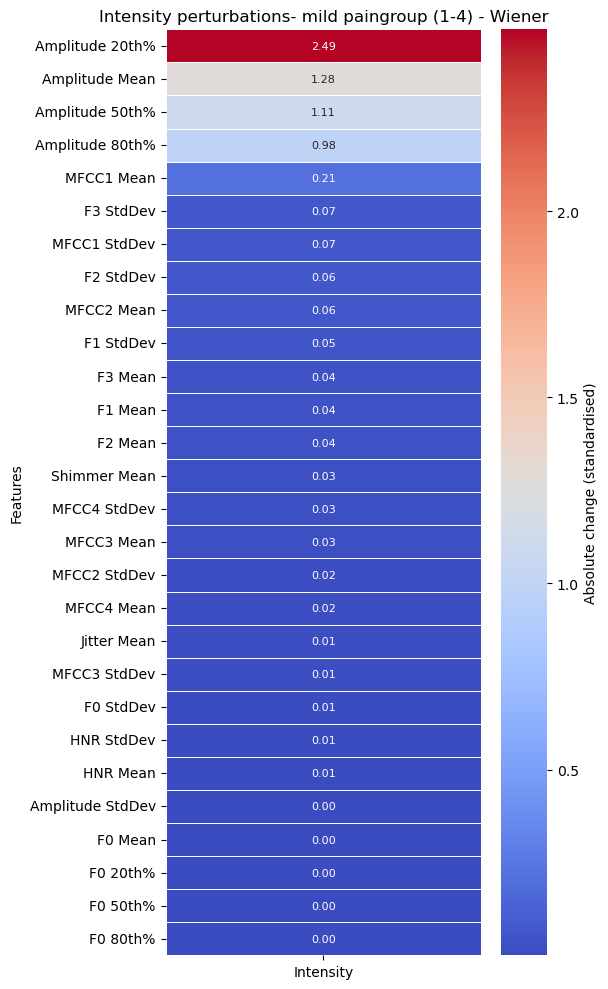

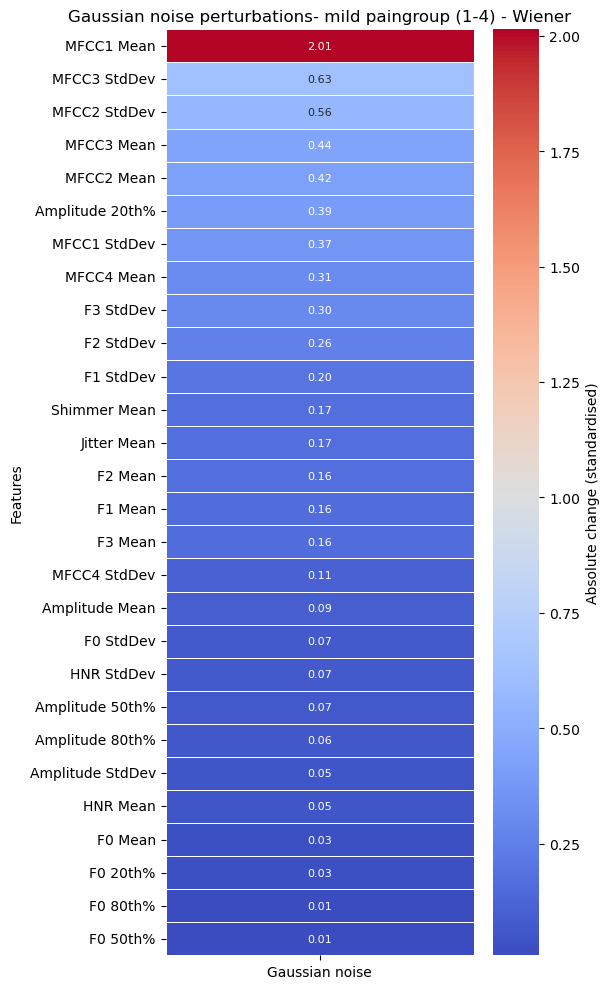

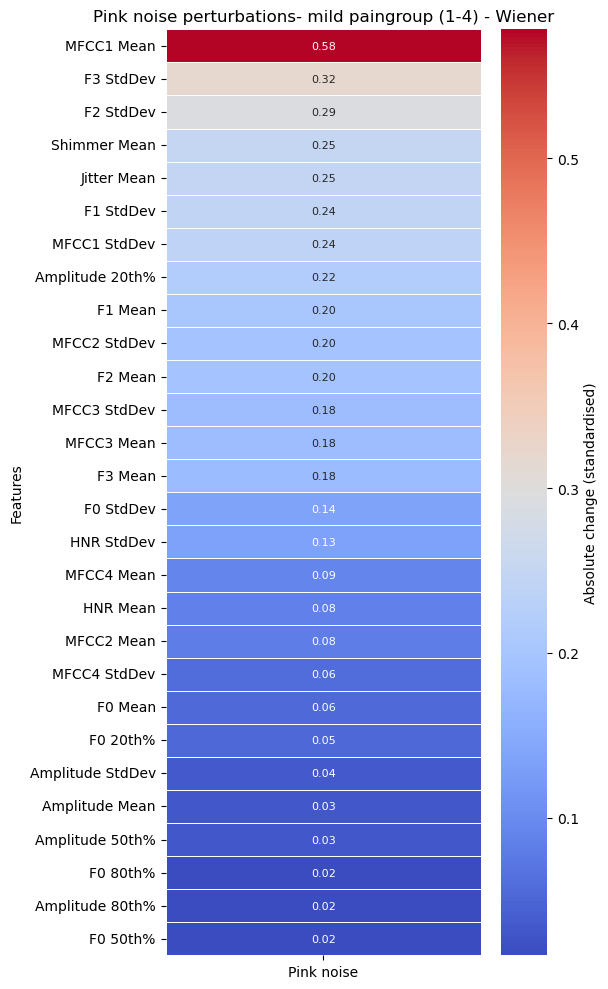

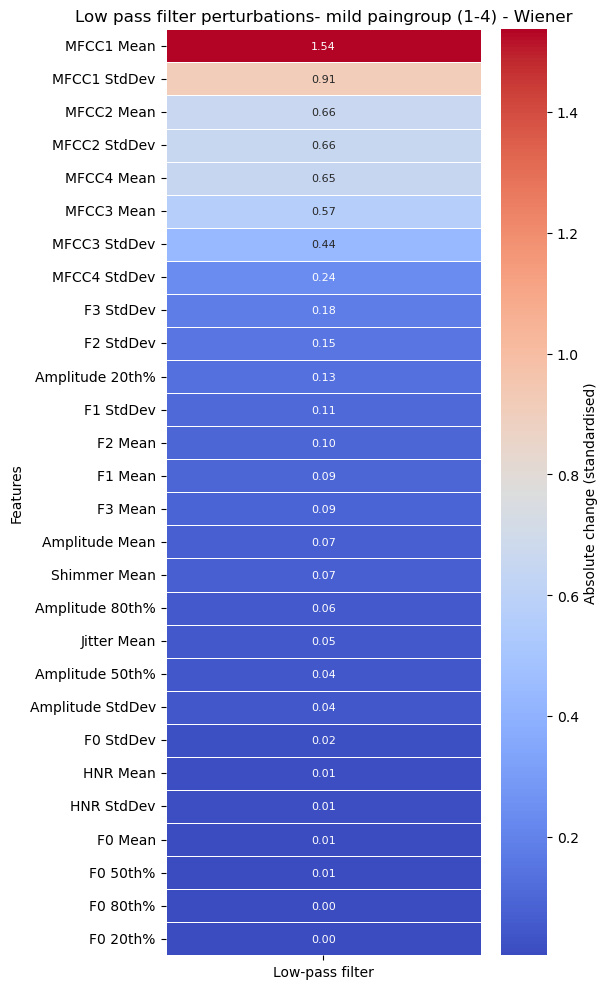


===== Running wiener_pain_group_5_to_6 =====
Feature sensitivity table saved to:
C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_original_based_scaling_wiener_pain_group_5_to_6.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.003177        0.037497    0.058974         0.007470
F0 20th%           0.004658        0.075998    0.094191         0.012621
F0 50th%           0.002187        0.019671    0.038185         0.004844
F0 80th%           0.000620        0.006538    0.011201         0.001950
F0 StdDev          0.006630        0.063914    0.105211         0.011655
F1 Mean            0.041378        0.156577    0.207147         0.092036
F1 StdDev          0.045105        0.193889    0.260599         0.100286
F2 Mean            0.039506        0.160633    0.192007         0.098940
F2 StdDev          0.060790        0.236338    0.297588         0.138800
F3 Mean            0.

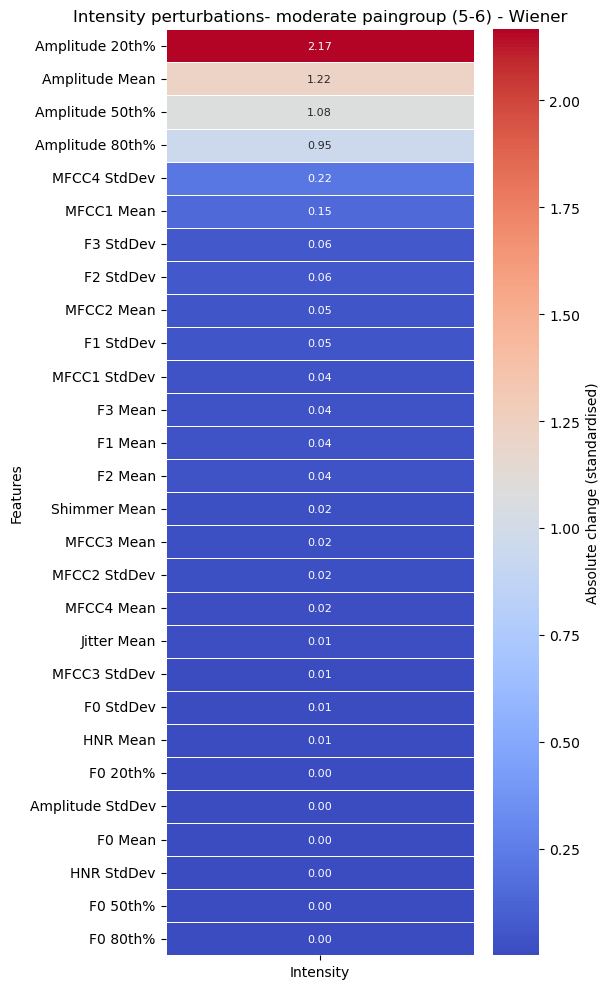

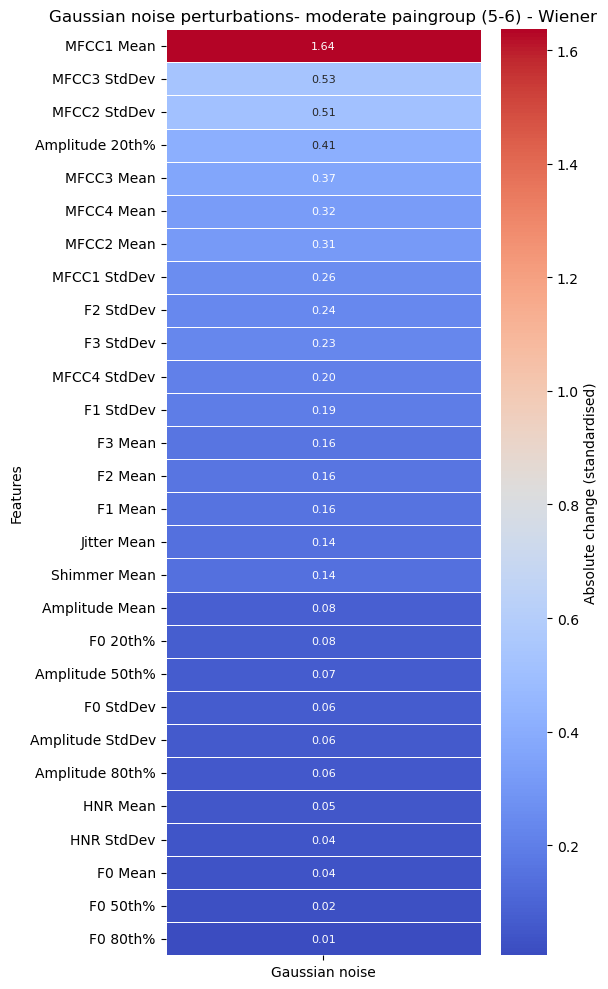

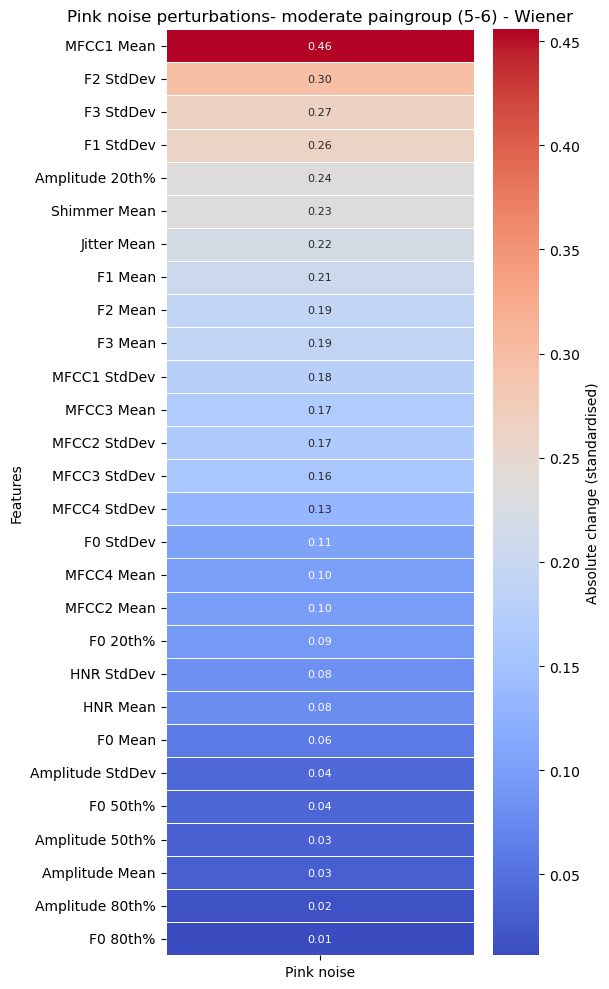

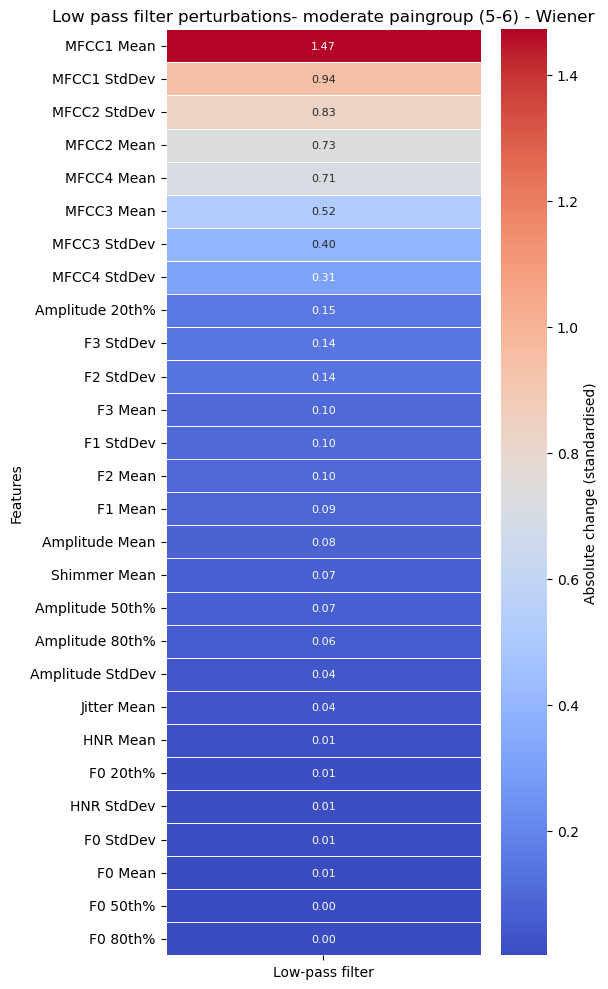


===== Running wiener_pain_group_7_to_10 =====
Feature sensitivity table saved to:
C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_original_based_scaling_wiener_pain_group_7_to_10.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.003503        0.034530    0.051435         0.008969
F0 20th%           0.004164        0.041291    0.056376         0.009800
F0 50th%           0.001041        0.014327    0.032969         0.004336
F0 80th%           0.001774        0.007485    0.010658         0.003115
F0 StdDev          0.010139        0.098973    0.161255         0.025692
F1 Mean            0.055667        0.184587    0.239113         0.121880
F1 StdDev          0.067482        0.264830    0.330199         0.161309
F2 Mean            0.053557        0.193210    0.237190         0.118266
F2 StdDev          0.075843        0.292253    0.335064         0.160871
F3 Mean            

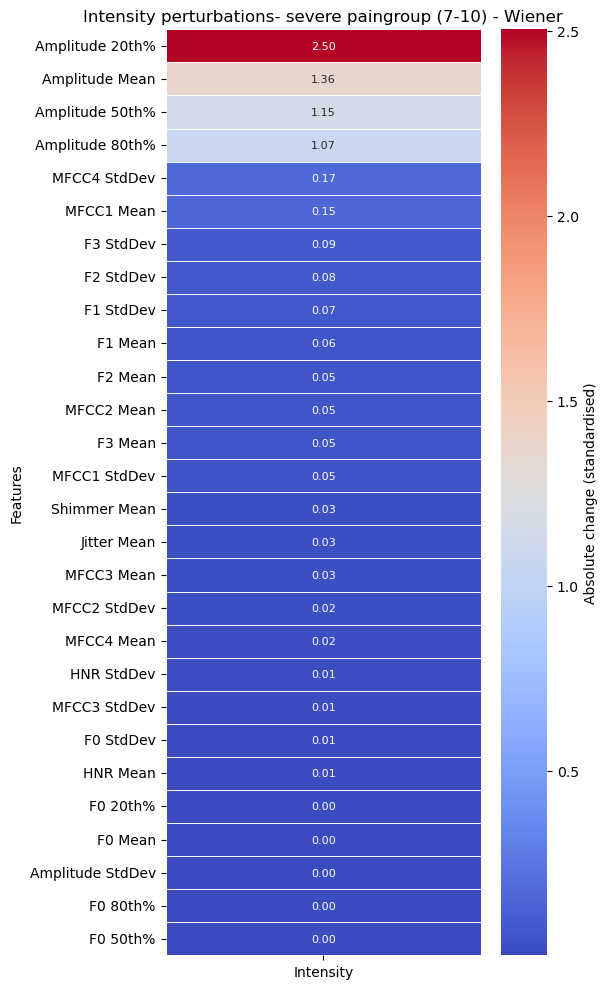

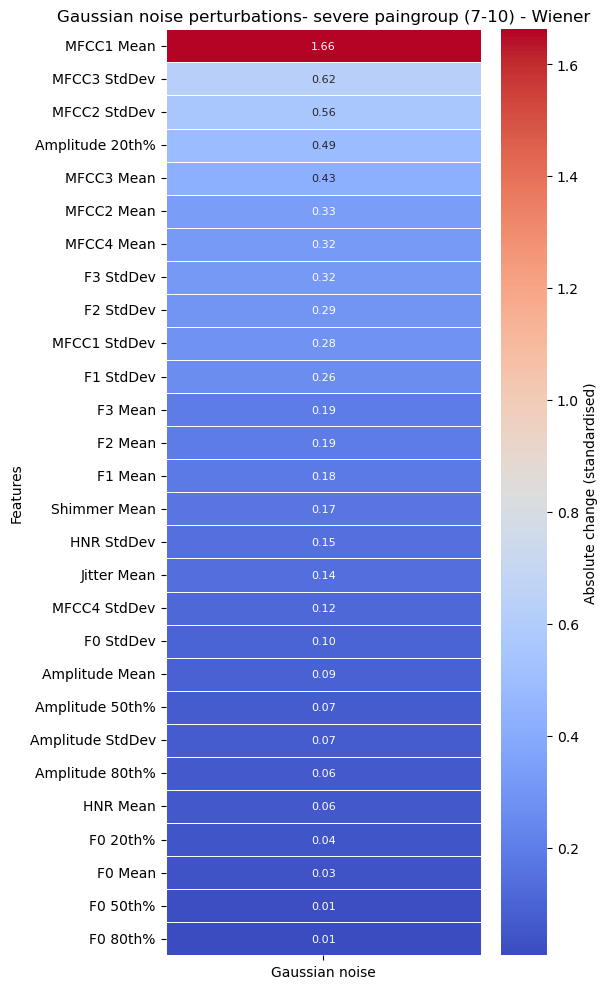

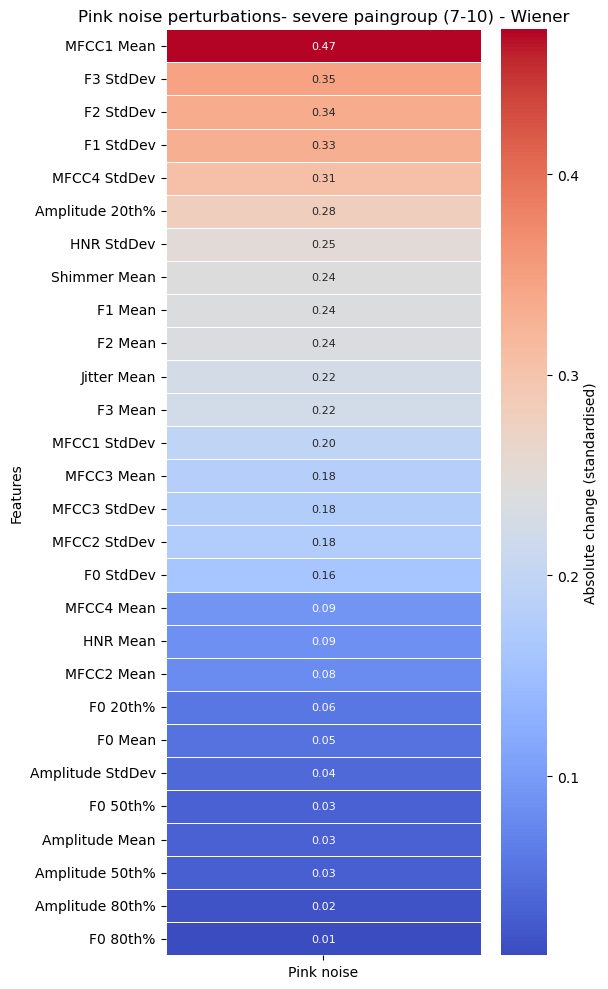

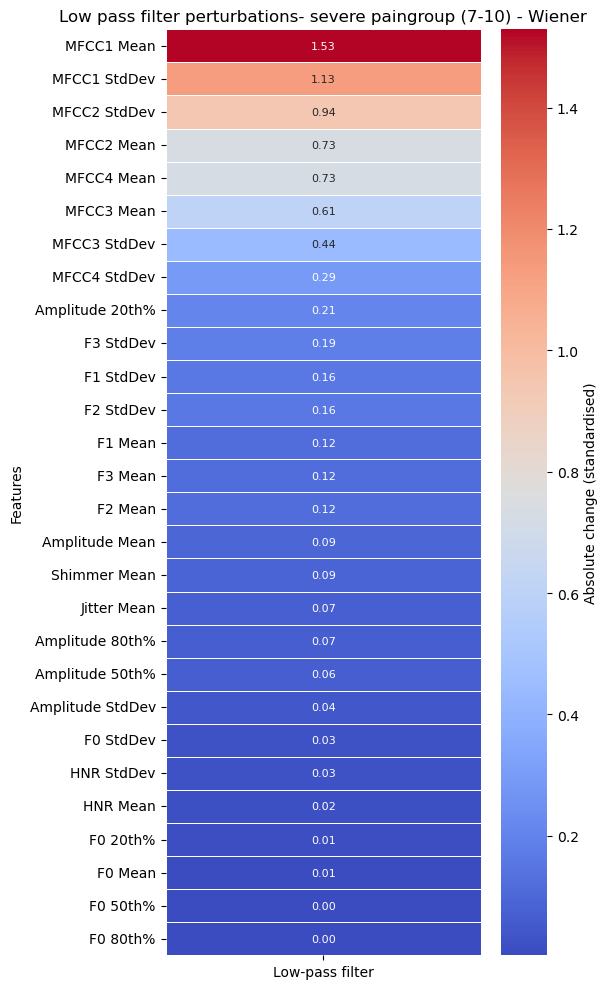

In [ ]:
# Paths
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

RUN_ORIGINAL = False
RUN_WIENER = True

RUN_GROUP_1_TO_4 = True
RUN_GROUP_5_TO_6 = True
RUN_GROUP_7_TO_10 = True

OUTPUT_FILES = {
    "original_pain_group_1_to_4": BASE_PATH / "feature_sensitivity_table_original_based_scaling_original_pain_group_1_to_4.csv",
    "wiener_pain_group_1_to_4": BASE_PATH / "feature_sensitivity_table_original_based_scaling_wiener_pain_group_1_to_4.csv",
    "original_pain_group_5_to_6": BASE_PATH / "feature_sensitivity_table_original_based_scaling_original_pain_group_5_to_6.csv",
    "wiener_pain_group_5_to_6": BASE_PATH / "feature_sensitivity_table_original_based_scaling_wiener_pain_group_5_to_6.csv",
    "original_pain_group_7_to_10": BASE_PATH / "feature_sensitivity_table_original_based_scaling_original_pain_group_7_to_10.csv",
    "wiener_pain_group_7_to_10": BASE_PATH / "feature_sensitivity_table_original_based_scaling_wiener_pain_group_7_to_10.csv",
}

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation_original_based_scaling_pain_groups"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

# Selected features
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# Perturbation groups
PERTURBATION_GROUPS = {}

if RUN_ORIGINAL and RUN_GROUP_1_TO_4:
    PERTURBATION_GROUPS["original_pain_group_1_to_4"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain_group_1_to_4_features_pain_original.csv",
            "-6": BASE_PATH / "opensmile_intensity_-6dB_pain_group_1_to_4_features_pain_original.csv",
            "-3": BASE_PATH / "opensmile_intensity_-3dB_pain_group_1_to_4_features_pain_original.csv",
            "+3": BASE_PATH / "opensmile_intensity_3dB_pain_group_1_to_4_features_pain_original.csv",
            "+6": BASE_PATH / "opensmile_intensity_6dB_pain_group_1_to_4_features_pain_original.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain_group_1_to_4_features_pain_original.csv",
            "0.5": BASE_PATH / "opensmile_low_gaussian_pain_group_1_to_4_features_pain_original.csv",
            "2": BASE_PATH / "opensmile_medium_gaussian_pain_group_1_to_4_features_pain_original.csv",
            "5": BASE_PATH / "opensmile_high_gaussian_pain_group_1_to_4_features_pain_original.csv",
            "10": BASE_PATH / "opensmile_very_high_gaussian_pain_group_1_to_4_features_pain_original.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain_group_1_to_4_features_pain_original.csv",
            "0.5": BASE_PATH / "opensmile_low_pink_pain_group_1_to_4_features_pain_original.csv",
            "2": BASE_PATH / "opensmile_medium_pink_pain_group_1_to_4_features_pain_original.csv",
            "5": BASE_PATH / "opensmile_high_pink_pain_group_1_to_4_features_pain_original.csv",
            "10": BASE_PATH / "opensmile_very_high_pink_pain_group_1_to_4_features_pain_original.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain_group_1_to_4_features_pain_original.csv",
            "6000": BASE_PATH / "opensmile_low_lowpass_pain_group_1_to_4_features_pain_original.csv",
            "5000": BASE_PATH / "opensmile_medium_lowpass_pain_group_1_to_4_features_pain_original.csv",
            "4000": BASE_PATH / "opensmile_high_lowpass_pain_group_1_to_4_features_pain_original.csv",
            "3000": BASE_PATH / "opensmile_very_high_lowpass_pain_group_1_to_4_features_pain_original.csv",
        },
    }

if RUN_WIENER and RUN_GROUP_1_TO_4:
    PERTURBATION_GROUPS["wiener_pain_group_1_to_4"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_1_to_4_features_pain.csv",
            "-6": BASE_PATH / "opensmile_intensity_-6dB_pain_group_1_to_4_features_pain.csv",
            "-3": BASE_PATH / "opensmile_intensity_-3dB_pain_group_1_to_4_features_pain.csv",
            "+3": BASE_PATH / "opensmile_intensity_3dB_pain_group_1_to_4_features_pain.csv",
            "+6": BASE_PATH / "opensmile_intensity_6dB_pain_group_1_to_4_features_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_1_to_4_features_pain.csv",
            "0.5": BASE_PATH / "opensmile_low_gaussian_pain_group_1_to_4_features_pain.csv",
            "2": BASE_PATH / "opensmile_medium_gaussian_pain_group_1_to_4_features_pain.csv",
            "5": BASE_PATH / "opensmile_high_gaussian_pain_group_1_to_4_features_pain.csv",
            "10": BASE_PATH / "opensmile_very_high_gaussian_pain_group_1_to_4_features_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_1_to_4_features_pain.csv",
            "0.5": BASE_PATH / "opensmile_low_pink_pain_group_1_to_4_features_pain.csv",
            "2": BASE_PATH / "opensmile_medium_pink_pain_group_1_to_4_features_pain.csv",
            "5": BASE_PATH / "opensmile_high_pink_pain_group_1_to_4_features_pain.csv",
            "10": BASE_PATH / "opensmile_very_high_pink_pain_group_1_to_4_features_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_1_to_4_features_pain.csv",
            "6000": BASE_PATH / "opensmile_low_lowpass_pain_group_1_to_4_features_pain.csv",
            "5000": BASE_PATH / "opensmile_medium_lowpass_pain_group_1_to_4_features_pain.csv",
            "4000": BASE_PATH / "opensmile_high_lowpass_pain_group_1_to_4_features_pain.csv",
            "3000": BASE_PATH / "opensmile_very_high_lowpass_pain_group_1_to_4_features_pain.csv",
        },
    }

if RUN_ORIGINAL and RUN_GROUP_5_TO_6:
    PERTURBATION_GROUPS["original_pain_group_5_to_6"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain_group_5_to_6_features_pain_original.csv",
            "-6": BASE_PATH / "opensmile_intensity_-6dB_pain_group_5_to_6_features_pain_original.csv",
            "-3": BASE_PATH / "opensmile_intensity_-3dB_pain_group_5_to_6_features_pain_original.csv",
            "+3": BASE_PATH / "opensmile_intensity_3dB_pain_group_5_to_6_features_pain_original.csv",
            "+6": BASE_PATH / "opensmile_intensity_6dB_pain_group_5_to_6_features_pain_original.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain_group_5_to_6_features_pain_original.csv",
            "0.5": BASE_PATH / "opensmile_low_gaussian_pain_group_5_to_6_features_pain_original.csv",
            "2": BASE_PATH / "opensmile_medium_gaussian_pain_group_5_to_6_features_pain_original.csv",
            "5": BASE_PATH / "opensmile_high_gaussian_pain_group_5_to_6_features_pain_original.csv",
            "10": BASE_PATH / "opensmile_very_high_gaussian_pain_group_5_to_6_features_pain_original.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain_group_5_to_6_features_pain_original.csv",
            "0.5": BASE_PATH / "opensmile_low_pink_pain_group_5_to_6_features_pain_original.csv",
            "2": BASE_PATH / "opensmile_medium_pink_pain_group_5_to_6_features_pain_original.csv",
            "5": BASE_PATH / "opensmile_high_pink_pain_group_5_to_6_features_pain_original.csv",
            "10": BASE_PATH / "opensmile_very_high_pink_pain_group_5_to_6_features_pain_original.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain_group_5_to_6_features_pain_original.csv",
            "6000": BASE_PATH / "opensmile_low_lowpass_pain_group_5_to_6_features_pain_original.csv",
            "5000": BASE_PATH / "opensmile_medium_lowpass_pain_group_5_to_6_features_pain_original.csv",
            "4000": BASE_PATH / "opensmile_high_lowpass_pain_group_5_to_6_features_pain_original.csv",
            "3000": BASE_PATH / "opensmile_very_high_lowpass_pain_group_5_to_6_features_pain_original.csv",
        },
    }

if RUN_WIENER and RUN_GROUP_5_TO_6:
    PERTURBATION_GROUPS["wiener_pain_group_5_to_6"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_5_to_6_features_pain.csv",
            "-6": BASE_PATH / "opensmile_intensity_-6dB_pain_group_5_to_6_features_pain.csv",
            "-3": BASE_PATH / "opensmile_intensity_-3dB_pain_group_5_to_6_features_pain.csv",
            "+3": BASE_PATH / "opensmile_intensity_3dB_pain_group_5_to_6_features_pain.csv",
            "+6": BASE_PATH / "opensmile_intensity_6dB_pain_group_5_to_6_features_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_5_to_6_features_pain.csv",
            "0.5": BASE_PATH / "opensmile_low_gaussian_pain_group_5_to_6_features_pain.csv",
            "2": BASE_PATH / "opensmile_medium_gaussian_pain_group_5_to_6_features_pain.csv",
            "5": BASE_PATH / "opensmile_high_gaussian_pain_group_5_to_6_features_pain.csv",
            "10": BASE_PATH / "opensmile_very_high_gaussian_pain_group_5_to_6_features_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_5_to_6_features_pain.csv",
            "0.5": BASE_PATH / "opensmile_low_pink_pain_group_5_to_6_features_pain.csv",
            "2": BASE_PATH / "opensmile_medium_pink_pain_group_5_to_6_features_pain.csv",
            "5": BASE_PATH / "opensmile_high_pink_pain_group_5_to_6_features_pain.csv",
            "10": BASE_PATH / "opensmile_very_high_pink_pain_group_5_to_6_features_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_5_to_6_features_pain.csv",
            "6000": BASE_PATH / "opensmile_low_lowpass_pain_group_5_to_6_features_pain.csv",
            "5000": BASE_PATH / "opensmile_medium_lowpass_pain_group_5_to_6_features_pain.csv",
            "4000": BASE_PATH / "opensmile_high_lowpass_pain_group_5_to_6_features_pain.csv",
            "3000": BASE_PATH / "opensmile_very_high_lowpass_pain_group_5_to_6_features_pain.csv",
        },
    }

if RUN_ORIGINAL and RUN_GROUP_7_TO_10:
    PERTURBATION_GROUPS["original_pain_group_7_to_10"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain_group_7_to_10_features_pain_original.csv",
            "-6": BASE_PATH / "opensmile_intensity_-6dB_pain_group_7_to_10_features_pain_original.csv",
            "-3": BASE_PATH / "opensmile_intensity_-3dB_pain_group_7_to_10_features_pain_original.csv",
            "+3": BASE_PATH / "opensmile_intensity_3dB_pain_group_7_to_10_features_pain_original.csv",
            "+6": BASE_PATH / "opensmile_intensity_6dB_pain_group_7_to_10_features_pain_original.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain_group_7_to_10_features_pain_original.csv",
            "0.5": BASE_PATH / "opensmile_low_gaussian_pain_group_7_to_10_features_pain_original.csv",
            "2": BASE_PATH / "opensmile_medium_gaussian_pain_group_7_to_10_features_pain_original.csv",
            "5": BASE_PATH / "opensmile_high_gaussian_pain_group_7_to_10_features_pain_original.csv",
            "10": BASE_PATH / "opensmile_very_high_gaussian_pain_group_7_to_10_features_pain_original.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain_group_7_to_10_features_pain_original.csv",
            "0.5": BASE_PATH / "opensmile_low_pink_pain_group_7_to_10_features_pain_original.csv",
            "2": BASE_PATH / "opensmile_medium_pink_pain_group_7_to_10_features_pain_original.csv",
            "5": BASE_PATH / "opensmile_high_pink_pain_group_7_to_10_features_pain_original.csv",
            "10": BASE_PATH / "opensmile_very_high_pink_pain_group_7_to_10_features_pain_original.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain_group_7_to_10_features_pain_original.csv",
            "6000": BASE_PATH / "opensmile_low_lowpass_pain_group_7_to_10_features_pain_original.csv",
            "5000": BASE_PATH / "opensmile_medium_lowpass_pain_group_7_to_10_features_pain_original.csv",
            "4000": BASE_PATH / "opensmile_high_lowpass_pain_group_7_to_10_features_pain_original.csv",
            "3000": BASE_PATH / "opensmile_very_high_lowpass_pain_group_7_to_10_features_pain_original.csv",
        },
    }

if RUN_WIENER and RUN_GROUP_7_TO_10:
    PERTURBATION_GROUPS["wiener_pain_group_7_to_10"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_7_to_10_features_pain.csv",
            "-6": BASE_PATH / "opensmile_intensity_-6dB_pain_group_7_to_10_features_pain.csv",
            "-3": BASE_PATH / "opensmile_intensity_-3dB_pain_group_7_to_10_features_pain.csv",
            "+3": BASE_PATH / "opensmile_intensity_3dB_pain_group_7_to_10_features_pain.csv",
            "+6": BASE_PATH / "opensmile_intensity_6dB_pain_group_7_to_10_features_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_7_to_10_features_pain.csv",
            "0.5": BASE_PATH / "opensmile_low_gaussian_pain_group_7_to_10_features_pain.csv",
            "2": BASE_PATH / "opensmile_medium_gaussian_pain_group_7_to_10_features_pain.csv",
            "5": BASE_PATH / "opensmile_high_gaussian_pain_group_7_to_10_features_pain.csv",
            "10": BASE_PATH / "opensmile_very_high_gaussian_pain_group_7_to_10_features_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_7_to_10_features_pain.csv",
            "0.5": BASE_PATH / "opensmile_low_pink_pain_group_7_to_10_features_pain.csv",
            "2": BASE_PATH / "opensmile_medium_pink_pain_group_7_to_10_features_pain.csv",
            "5": BASE_PATH / "opensmile_high_pink_pain_group_7_to_10_features_pain.csv",
            "10": BASE_PATH / "opensmile_very_high_pink_pain_group_7_to_10_features_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain_group_7_to_10_features_pain.csv",
            "6000": BASE_PATH / "opensmile_low_lowpass_pain_group_7_to_10_features_pain.csv",
            "5000": BASE_PATH / "opensmile_medium_lowpass_pain_group_7_to_10_features_pain.csv",
            "4000": BASE_PATH / "opensmile_high_lowpass_pain_group_7_to_10_features_pain.csv",
            "3000": BASE_PATH / "opensmile_very_high_lowpass_pain_group_7_to_10_features_pain.csv",
        },
    }

if not PERTURBATION_GROUPS:
    raise ValueError("Set at least one RUN_* option to True.")

# Functions
def load_and_sort_csv(file_path):
    """
    Load CSV file and sort by participant_id and filename to ensure alignment across files.
    """
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def check_alignment(reference_df, comparison_df, label):
    """
    Control the alignment of two DataFrames by comparing their participant_id and filename columns.
    """
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


def run_sensitivity_analysis(perturbation_groups, output_file):
    """
    For each perturbation group, calculate the average absolute change in standardised feature values compared to the original, and save results to CSV.
    """
    
    all_data = {}

    for group_name, files in perturbation_groups.items():
        all_data[group_name] = {}
        for level_label, file_path in files.items():
            all_data[group_name][level_label] = load_and_sort_csv(file_path)

    for group_name, dfs in all_data.items():
        original_df = dfs["original"]
        for level_label, df in dfs.items():
            if level_label == "original":
                continue
            check_alignment(original_df, df, f"{group_name} - {level_label}")

    reference_original = all_data["Intensity"]["original"]
    feature_cols = list(selected_features.values())

    missing_features = [
        feature_col for feature_col in feature_cols
        if feature_col not in reference_original.columns
    ]
    if missing_features:
        raise ValueError(f"These features are missing from the CSV files: {missing_features}")

    results = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    for group_name, dfs in all_data.items():
        scaler = StandardScaler()
        scaler.fit(dfs["original"][feature_cols])

        original_std = scaler.transform(dfs["original"][feature_cols])

        for i, feature_name in enumerate(selected_features.keys()):
            level_scores = []

            for level_label, df in dfs.items():
                if level_label == "original":
                    continue

                perturbed_std = scaler.transform(df[feature_cols])
                abs_diff = np.abs(original_std[:, i] - perturbed_std[:, i])
                level_scores.append(abs_diff.mean())

            results.loc[feature_name, group_name] = np.mean(level_scores)

    results.to_csv(output_file)
    print("Feature sensitivity table saved to:")
    print(output_file)
    print()
    print(results)

    return results


def format_dataset_label(dataset_name):
    """
    Format dataset name into more readable labels for heatmap titles.
    """
    if "wiener" in dataset_name.lower():
        data_label = "Wiener"
    else:
        data_label = "Original"

    if "1_to_4" in dataset_name:
        pain_label = "mild paingroup (1-4)"
    elif "5_to_6" in dataset_name:
        pain_label = "moderate paingroup (5-6)"
    elif "7_to_10" in dataset_name:
        pain_label = "severe paingroup (7-10)"
    else:
        pain_label = dataset_name

    return pain_label, data_label


def save_heatmaps(results_df, dataset_name, heatmap_dir):
    """
    Save heatmaps for each perturbation group in the dataset, with formatted titles.
    """
    dataset_heatmap_dir = heatmap_dir / dataset_name
    dataset_heatmap_dir.mkdir(parents=True, exist_ok=True)

    pain_label, data_label = format_dataset_label(dataset_name)

    for group_name in results_df.columns:
        heatmap_data = results_df[[group_name]].copy()
        heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

        nice_group_name = group_name
        if group_name == "Low-pass filter":
            nice_group_name = "Low pass filter"

        plt.figure(figsize=(6, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={"label": "Absolute change (standardised)"},
            linewidths=0.5,
            cbar=True,
            annot_kws={"size": 8}
        )

        plt.title(f"{nice_group_name} perturbations- {pain_label} - {data_label}")
        plt.xlabel("")
        plt.ylabel("Features")
        plt.tight_layout()

        plt.savefig(
            dataset_heatmap_dir / f"heatmap_{group_name.replace(' ', '_')}_{dataset_name}.png",
            dpi=300
        )
        plt.show()
        plt.close()


# Run
all_results = {}

for dataset_name, perturbation_groups in PERTURBATION_GROUPS.items():
    print(f"===== Running {dataset_name} =====")

    results = run_sensitivity_analysis(
        perturbation_groups=perturbation_groups,
        output_file=OUTPUT_FILES[dataset_name]
    )

    all_results[dataset_name] = results
    save_heatmaps(results, dataset_name, HEATMAP_DIR)

    print()

Create a more nice figure 

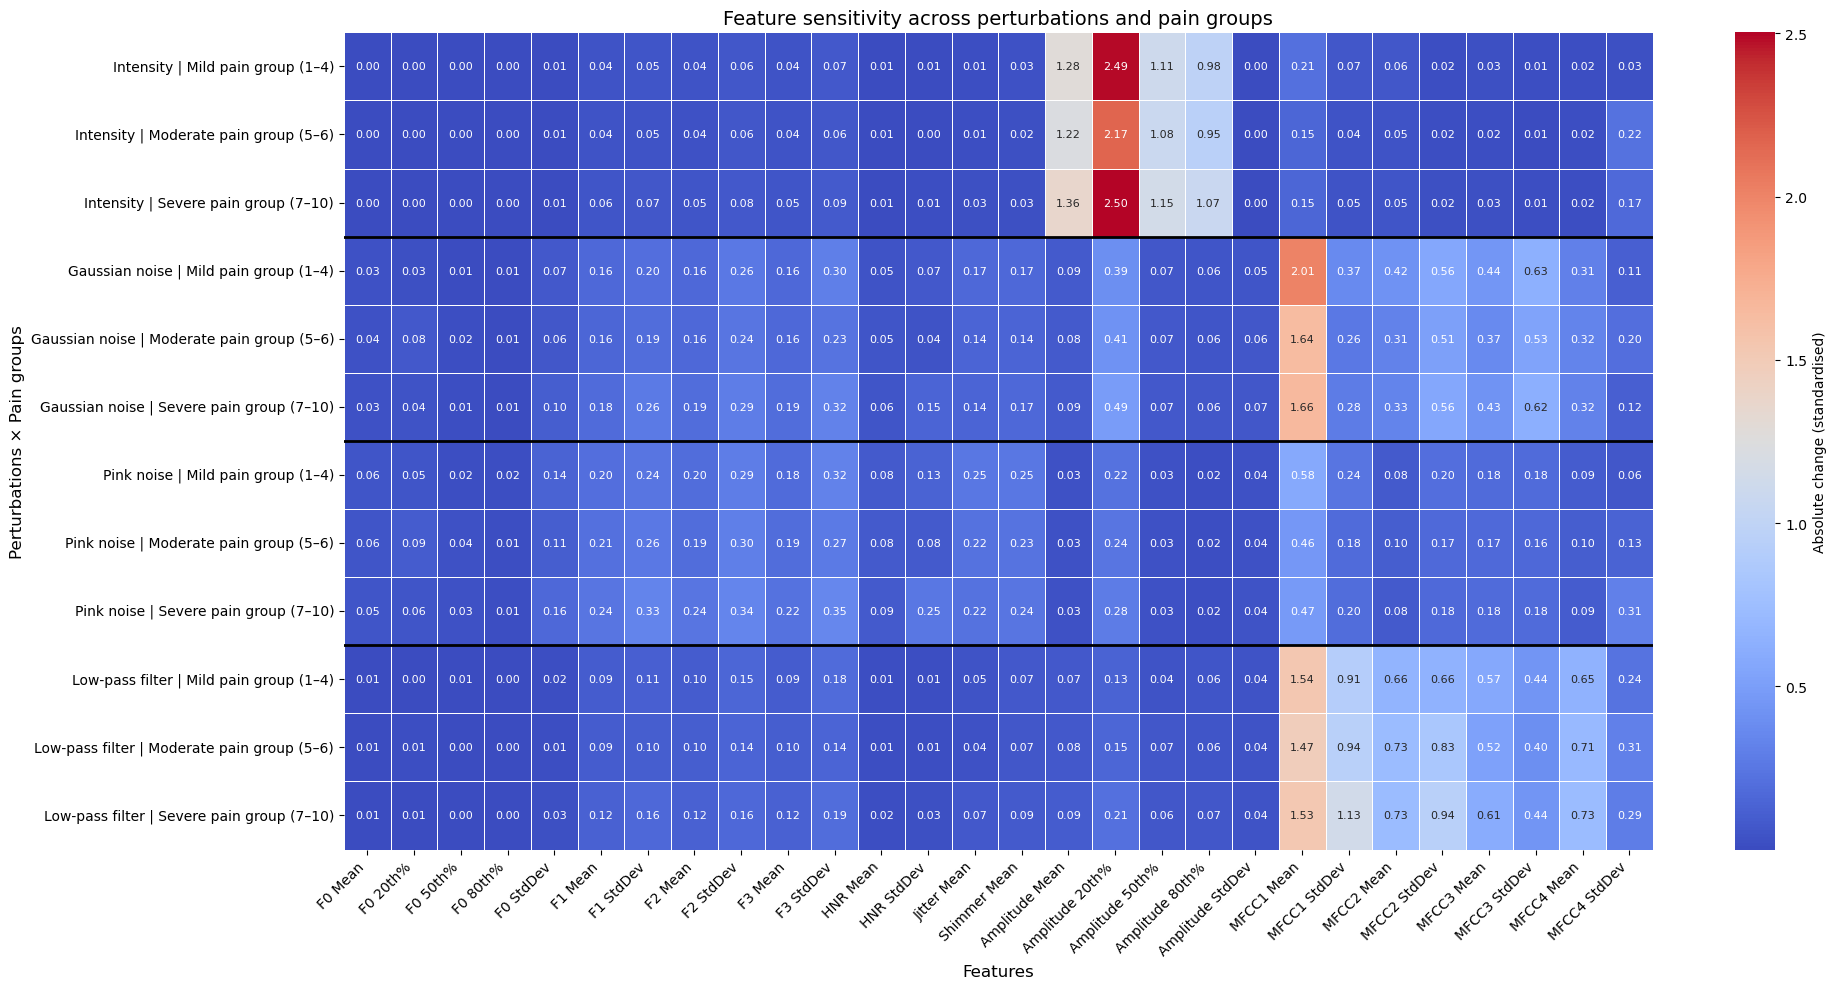

In [ ]:
def add_group_separators(ax, combined_df, perturbations):
    """
    Add horizontal lines to separate groups of rows corresponding to different perturbations in the heatmap.
    """
    current = 0
    for perturbation in perturbations:
        count = sum(idx.startswith(perturbation) for idx in combined_df.index)
        current += count
        if current < len(combined_df.index):
            ax.axhline(current, color="black", linewidth=2)


def plot_combined_feature_heatmap_wiener(all_results, heatmap_dir=None, save_fig=True):
    """
    Make heatmap that combines all perturbation groups (wiener) and pain groups into one figure, to visually compare feature sensitivity across all conditions.
    """

    dataset_keys = {
        "Mild pain group (1–4)": "wiener_pain_group_1_to_4",
        "Moderate pain group (5–6)": "wiener_pain_group_5_to_6",
        "Severe pain group (7–10)": "wiener_pain_group_7_to_10",
    }

    perturbations = [
        "Intensity",
        "Gaussian noise",
        "Pink noise",
        "Low-pass filter",
    ]

    rows = []

    # Dataframe opbouwen: rijen = perturbation × pain group
    for perturbation in perturbations:
        for group_name, dataset_key in dataset_keys.items():
            df = all_results[dataset_key]

            row = df[perturbation].copy()
            row.name = f"{perturbation} | {group_name}"
            rows.append(row)

    combined_df = pd.DataFrame(rows)

    FEATURE_GROUPS = {
    "F0": [
        "F0 Mean", "F0 20th%", "F0 50th%", "F0 80th%", "F0 StdDev"
    ],
    "Formants": [
        "F1 Mean", "F1 StdDev",
        "F2 Mean", "F2 StdDev",
        "F3 Mean", "F3 StdDev",
    ],
    "Voice quality": [
        "HNR Mean", "HNR StdDev",
        "Jitter Mean",
        "Shimmer Mean"
    ],
    "Amplitude": [
        "Amplitude Mean",
        "Amplitude 20th%",
        "Amplitude 50th%",
        "Amplitude 80th%",
        "Amplitude StdDev"
    ],
    "MFCC": [
        "MFCC1 Mean", "MFCC1 StdDev",
        "MFCC2 Mean", "MFCC2 StdDev",
        "MFCC3 Mean", "MFCC3 StdDev",
        "MFCC4 Mean", "MFCC4 StdDev",
    ]
}

    # Features order grouped by type
    feature_order = []
    for group in FEATURE_GROUPS.values():
        feature_order.extend([f for f in group if f in combined_df.columns])

    combined_df = combined_df[feature_order]


    # Plot
    plt.figure(figsize=(20, 10))

    ax = sns.heatmap(
        combined_df,
        cmap="coolwarm",
        linewidths=0.5,
        linecolor="white",
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "Absolute change (standardised)"},
        annot_kws={"size": 8}
    )

    # Add lines to separate perturbation groups
    add_group_separators(ax, combined_df, perturbations)

    plt.title("Feature sensitivity across perturbations and pain groups", fontsize=14)
    plt.xlabel("Features", fontsize=12)
    plt.ylabel("Perturbations × Pain groups", fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()

    if save_fig and heatmap_dir is not None:
        filename = "combined_wiener_feature_heatmap.png"
        plt.savefig(heatmap_dir / filename, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

    return combined_df

combined_df_wiener = plot_combined_feature_heatmap_wiener(
    all_results=all_results,
    heatmap_dir=HEATMAP_DIR,
    save_fig=True
)
